# KPI Tree / Driver Decomposition

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/kpi-tree/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/kpi-tree/demo.ipynb)

> "Why did revenue move?" — this splits a KPI's change across its drivers, exactly, with no residual.

Revenue dropped 5% and the room turns to guesses: fewer users? worse conversion? lower price? A KPI
tree answers it *arithmetically*. Model revenue as `users × conversion × ARPU`, and an **LMDI
decomposition** attributes the total change to each driver so the pieces add up to exactly the whole
- no fudge factor.

**What this notebook covers**
1. A KPI as a product of drivers
2. Why naive attribution leaves a residual
3. LMDI decomposition (exact, additive)
4. A plain-English driver story
5. The classic waterfall, visualized


## Step 1 - The KPI and its drivers

`Revenue = Active users × Conversion rate × ARPU`. Between two periods, every driver moved a
little; we want each one's fingerprint on the total.

In [1]:
from kpitree import (decomposition_summary, narrate,
                     REVENUE_TREE, SAMPLE_BEFORE, SAMPLE_AFTER)

print("Formula: Revenue =", " × ".join(REVENUE_TREE.label(d) for d in REVENUE_TREE.drivers), "\n")
for d in REVENUE_TREE.drivers:
    print(f"  {REVENUE_TREE.label(d):<16} {SAMPLE_BEFORE[d]:>10,.3f}  ->  {SAMPLE_AFTER[d]:>10,.3f}")
print(f"\n  Revenue          {REVENUE_TREE.value(SAMPLE_BEFORE):>10,.0f}  ->  {REVENUE_TREE.value(SAMPLE_AFTER):>10,.0f}")


Formula: Revenue = Active users × Conversion rate × ARPU 

  Active users     100,000.000  ->  118,000.000
  Conversion rate       0.040  ->       0.035
  ARPU                 50.000  ->      54.000

  Revenue             200,000  ->     223,020


## Step 2 - Why naive attribution fails

The tempting shortcut - "each driver's % change × starting revenue" - doesn't add up, because the
drivers interact (more users *and* higher price compound). The leftover is a **residual** nobody can
explain in the meeting.

In [2]:
kpi0 = REVENUE_TREE.value(SAMPLE_BEFORE)
kpi1 = REVENUE_TREE.value(SAMPLE_AFTER)
total = kpi1 - kpi0

naive = {d: (SAMPLE_AFTER[d] - SAMPLE_BEFORE[d]) / SAMPLE_BEFORE[d] * kpi0 for d in REVENUE_TREE.drivers}
naive_sum = sum(naive.values())
print("Naive (pct-change x base) attribution:")
for d, v in naive.items():
    print(f"  {REVENUE_TREE.label(d):<16} {v:>12,.0f}")
print(f"  {'sum':<16} {naive_sum:>12,.0f}")
print(f"  actual change    {total:>12,.0f}")
print(f"  RESIDUAL         {total - naive_sum:>12,.0f}  <- unexplained")


Naive (pct-change x base) attribution:
  Active users           36,000
  Conversion rate       -25,000
  ARPU                   16,000
  sum                    27,000
  actual change          23,020
  RESIDUAL               -3,980  <- unexplained


## Step 3 - LMDI: exact, additive attribution

The log-mean divisia index weights each driver's log-change by the log mean of the KPI. The math
guarantees the contributions sum to the *exact* total change - residual zero.

In [3]:
summary = decomposition_summary(REVENUE_TREE, SAMPLE_BEFORE, SAMPLE_AFTER)
for con in summary["contributions"]:
    print(f"  {con.label:<16} {con.pct_change:+6.1%}  ->  contributes {con.contribution:>+12,.0f}  ({con.share:+.0%} of change)")
print(f"\n  sum of contributions: {sum(c.contribution for c in summary['contributions']):>+12,.0f}")
print(f"  actual change:        {summary['total_change']:>+12,.0f}")
print(f"  residual:             {summary['residual']:>+12.6f}  <- exact")


  Active users     +18.0%  ->  contributes      +34,973  (+152% of change)
  Conversion rate  -12.5%  ->  contributes      -28,215  (-123% of change)
  ARPU              +8.0%  ->  contributes      +16,262  (+71% of change)

  sum of contributions:      +23,020
  actual change:             +23,020
  residual:                +0.000000  <- exact


## Step 4 - The one-line answer

The output a leader actually wants: what moved, by how much, biggest mover first. Here, growth in
users and ARPU more than offset a drop in conversion.

In [4]:
print(narrate(summary))


Revenue rose 23,020 (+12%): Active users added 34,973 (+18%); Conversion rate removed 28,215 (-12%); ARPU added 16,262 (+8%).


## Step 5 - The waterfall

Start at old revenue, add each driver's signed contribution, land on new revenue. Green builds,
red erodes - the whole story in one bar chart.

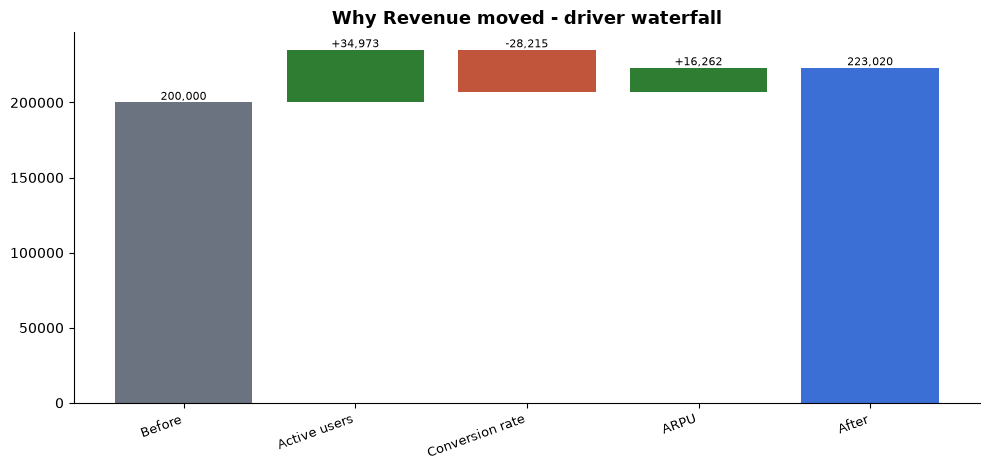

In [5]:
import matplotlib.pyplot as plt

contribs = summary["contributions"]
labels = ["Before"] + [c.label for c in contribs] + ["After"]
running = summary["before"]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(0, summary["before"], color="#6b7280")
ax.text(0, summary["before"], f"{summary['before']:,.0f}", ha="center", va="bottom", fontsize=8)
for i, con in enumerate(contribs, start=1):
    color = "#2e7d32" if con.contribution >= 0 else "#c0553b"
    bottom = running if con.contribution >= 0 else running + con.contribution
    ax.bar(i, abs(con.contribution), bottom=bottom, color=color)
    ax.text(i, bottom + abs(con.contribution), f"{con.contribution:+,.0f}", ha="center", va="bottom", fontsize=8)
    running += con.contribution
ax.bar(len(contribs) + 1, summary["after"], color="#3b6fd6")
ax.text(len(contribs) + 1, summary["after"], f"{summary['after']:,.0f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.set_title("Why Revenue moved - driver waterfall", fontsize=13, weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("waterfall.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Driver | % change | Contribution |
|--------|----------|--------------|
| Active users | +18% | +34,973 |
| Conversion | −12% | −28,215 |
| ARPU | +8% | +16,262 |
| **Total** | **+12%** | **+23,020** |

LMDI turns "why did it move?" from a debate into arithmetic. Contributions add up exactly, so the
biggest lever is unambiguous - here, conversion is quietly bleeding gains the other two drivers
create.

**Extend it:** nest trees (users = new + retained), run it every period on your warehouse, and alert
when any single driver's contribution crosses a threshold.

In [6]:
# --- Try your own KPI ---
# from kpitree import KpiTree, decomposition_summary, narrate
# tree = KpiTree("GMV", ["orders", "aov"], {"orders": "Orders", "aov": "Avg order value"})
# b = {"orders": 5000, "aov": 42}
# a = {"orders": 5600, "aov": 39}
# print(narrate(decomposition_summary(tree, b, a)))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 107,
Month 11: Analytics Engineering & BI.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`